In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Load classification problem 1 dataset
df = pd.read_csv("binary_dataset.csv")

print(df.head())
print(df.shape)
print(df.iloc[:, -1].value_counts(dropna=False))

   kills  deaths  assists  gold_earned  gold_spent  \
0     11      11       11        12570       11800   
1      0       7        5         8306        8155   
2      1       8       16        12148       11625   
3      1       6       16         7114        6200   
4      3       5        1         5136        4725   

   total_damage_dealt_to_champions  total_damage_taken  vision_score  \
0                            27500               54133            47   
1                            20100               19203            12   
2                            22068               38546           104   
3                            10973               21697            48   
4                             8134               13062            23   

   wards_placed  champion_mastery_points  win  
0            21                1756910.0    0  
1             7                 101684.0    0  
2            40                 236514.0    1  
3            25                  49634.0    1  
4 

In [3]:
# Features and response
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("Response variable:", df.columns[-1])
print("Number of features:", X.shape[1])

Response variable: win
Number of features: 10


In [4]:
# 90% training, 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
val_df = pd.concat([X_val.reset_index(drop=True), y_val.reset_index(drop=True)], axis=1)

train_df.to_csv("binary_train.csv", index=False)
val_df.to_csv("binary_validation.csv", index=False)

print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("\nTraining response distribution:")
print(y_train.value_counts(normalize=True))
print("\nValidation response distribution:")
print(y_val.value_counts(normalize=True))

Training set shape: (6545, 11)
Validation set shape: (728, 11)

Training response distribution:
win
1    0.504202
0    0.495798
Name: proportion, dtype: float64

Validation response distribution:
win
1    0.504121
0    0.495879
Name: proportion, dtype: float64


In [5]:
# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter values
k_values = [3, 5, 7, 9, 11]
rf_values = [50, 100, 150, 200, 300]

In [6]:
# KNN cross-validation on training set only
knn_means = []
knn_stds = []

for k in k_values:
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(knn_pipeline, X_train, y_train, cv=cv, scoring="accuracy")
    knn_means.append(scores.mean())
    knn_stds.append(scores.std())
    print(f"KNN, k={k}: mean={scores.mean():.4f}, std={scores.std():.4f}")

KNN, k=3: mean=0.7458, std=0.0057
KNN, k=5: mean=0.7644, std=0.0083
KNN, k=7: mean=0.7673, std=0.0061
KNN, k=9: mean=0.7760, std=0.0075
KNN, k=11: mean=0.7794, std=0.0066


In [7]:
# Random Forest cross-validation on training set only
rf_means = []
rf_stds = []

for n in rf_values:
    rf_model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    
    scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="accuracy")
    rf_means.append(scores.mean())
    rf_stds.append(scores.std())
    print(f"Random Forest, n_estimators={n}: mean={scores.mean():.4f}, std={scores.std():.4f}")

Random Forest, n_estimators=50: mean=0.7962, std=0.0082
Random Forest, n_estimators=100: mean=0.8000, std=0.0060
Random Forest, n_estimators=150: mean=0.7992, std=0.0061
Random Forest, n_estimators=200: mean=0.8044, std=0.0068
Random Forest, n_estimators=300: mean=0.8024, std=0.0059


In [8]:
# Save CV results into tables
knn_cv_results = pd.DataFrame({
    "k": k_values,
    "mean_cv_accuracy": knn_means,
    "std_cv_accuracy": knn_stds
})

rf_cv_results = pd.DataFrame({
    "n_estimators": rf_values,
    "mean_cv_accuracy": rf_means,
    "std_cv_accuracy": rf_stds
})

print("KNN CV Results")
print(knn_cv_results)

print("\nRandom Forest CV Results")
print(rf_cv_results)

KNN CV Results
    k  mean_cv_accuracy  std_cv_accuracy
0   3          0.745760         0.005745
1   5          0.764400         0.008321
2   7          0.767303         0.006142
3   9          0.776012         0.007476
4  11          0.779374         0.006649

Random Forest CV Results
   n_estimators  mean_cv_accuracy  std_cv_accuracy
0            50          0.796180         0.008219
1           100          0.800000         0.006004
2           150          0.799236         0.006081
3           200          0.804431         0.006850
4           300          0.802445         0.005910


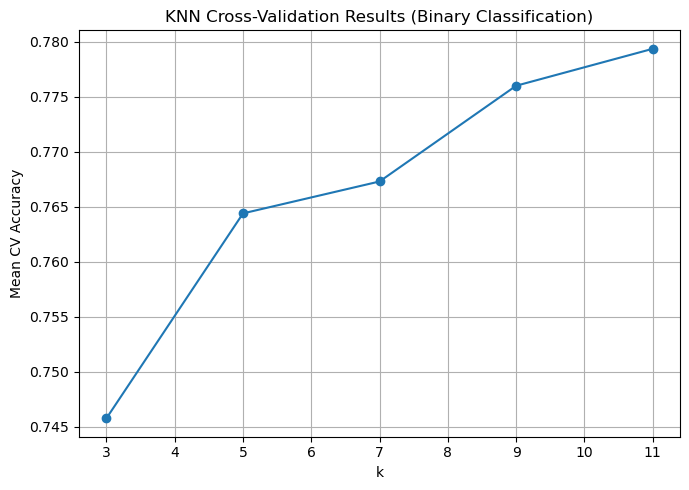

In [9]:
# Plot KNN CV results
plt.figure(figsize=(7, 5))
plt.plot(k_values, knn_means, marker="o")
plt.xlabel("k")
plt.ylabel("Mean CV Accuracy")
plt.title("KNN Cross-Validation Results (Binary Classification)")
plt.grid(True)
plt.tight_layout()
plt.savefig("knn_binary_cv.png", dpi=300)
plt.show()

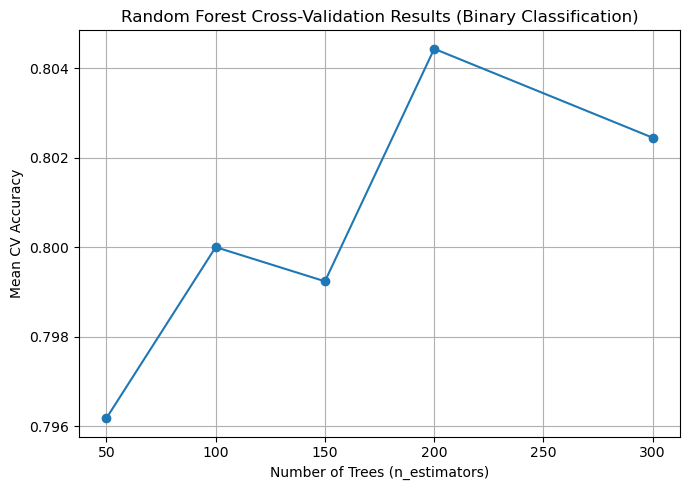

In [10]:
# Plot Random Forest CV results
plt.figure(figsize=(7, 5))
plt.plot(rf_values, rf_means, marker="o")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Mean CV Accuracy")
plt.title("Random Forest Cross-Validation Results (Binary Classification)")
plt.grid(True)
plt.tight_layout()
plt.savefig("rf_binary_cv.png", dpi=300)
plt.show()

In [11]:
# Choose best hyperparameters based on highest mean CV accuracy
best_k = k_values[int(np.argmax(knn_means))]
best_rf = rf_values[int(np.argmax(rf_means))]

best_knn_cv = max(knn_means)
best_rf_cv = max(rf_means)

print("Best KNN k:", best_k, "| Mean CV Accuracy:", best_knn_cv)
print("Best Random Forest n_estimators:", best_rf, "| Mean CV Accuracy:", best_rf_cv)

Best KNN k: 11 | Mean CV Accuracy: 0.7793735676088618
Best Random Forest n_estimators: 200 | Mean CV Accuracy: 0.8044308632543926


In [12]:
# Train final KNN model and measure training time
final_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

start_train_knn = time.perf_counter()
final_knn.fit(X_train, y_train)
end_train_knn = time.perf_counter()

knn_train_time = end_train_knn - start_train_knn

# Training performance
knn_train_pred = final_knn.predict(X_train)
knn_train_acc = accuracy_score(y_train, knn_train_pred)

print("Final KNN")
print("Training accuracy:", knn_train_acc)
print("Training time (seconds):", knn_train_time)

Final KNN
Training accuracy: 0.8195569136745607
Training time (seconds): 0.013557599995692726


In [13]:
# Validate final KNN model and measure testing time
start_test_knn = time.perf_counter()
knn_val_pred = final_knn.predict(X_val)
end_test_knn = time.perf_counter()

knn_test_time = end_test_knn - start_test_knn
knn_val_acc = accuracy_score(y_val, knn_val_pred)

print("Final KNN")
print("Validation accuracy:", knn_val_acc)
print("Testing time (seconds):", knn_test_time)

Final KNN
Validation accuracy: 0.7912087912087912
Testing time (seconds): 0.06176180000329623


In [14]:
# Train final Random Forest model and measure training time
final_rf = RandomForestClassifier(
    n_estimators=best_rf,
    random_state=42
)

start_train_rf = time.perf_counter()
final_rf.fit(X_train, y_train)
end_train_rf = time.perf_counter()

rf_train_time = end_train_rf - start_train_rf

# Training performance
rf_train_pred = final_rf.predict(X_train)
rf_train_acc = accuracy_score(y_train, rf_train_pred)

print("Final Random Forest")
print("Training accuracy:", rf_train_acc)
print("Training time (seconds):", rf_train_time)

Final Random Forest
Training accuracy: 1.0
Training time (seconds): 2.8129049000053783


In [15]:
# Validate final Random Forest model and measure testing time
start_test_rf = time.perf_counter()
rf_val_pred = final_rf.predict(X_val)
end_test_rf = time.perf_counter()

rf_test_time = end_test_rf - start_test_rf
rf_val_acc = accuracy_score(y_val, rf_val_pred)

print("Final Random Forest")
print("Validation accuracy:", rf_val_acc)
print("Testing time (seconds):", rf_test_time)

Final Random Forest
Validation accuracy: 0.7925824175824175
Testing time (seconds): 0.07254180000018096
